# Sinkhorn Distances on MNIST with k-NN

In this notebook, we explore the Sinkhorn distance, a concept from optimal transport.

We first introduce its theoretical formulation, then explain how it can be implemented in practice. Finally, we study a simple application: classifying MNIST images using a k-nearest neighbors classifier based on Sinkhorn distances.

Let us begin with the theoretical formulation.


## Theoretical formulation

Let $r$ and $c$ be two probability vectors, also called distributions, on the simplex $\Sigma_d$:

$$
\Sigma_d = \{ x \in \mathbb{R}^d_+ : \sum_{i=1}^d x_i = 1 \}.
$$

Let us suppose that each coordinate $r_i$ is the mass of a source point $x_i$, and each coordinate $c_j$ is the mass of a target point $y_j$.

Our goal is to measure the distance between the two distributions $r$ and $c$. To do that, we ask ourselves the following question: what is the least effort needed to go from $r$ to $c$?

We define:

$$
U(r,c) = \{ P \in \mathbb{R}^{d \times d}_+ : P1_d = r,\ P^T1_d = c \}.
$$

where $1_d$ is the column vector with $d$ ones as coefficients.

### Interpretation

Let $P \in U(r,c)$. The matrix $P$ is called a transportation matrix.

The coefficient $P_{i,j}$ represents the amount of mass that is transported from the point $x_i$ to the point $y_j$.

Then we have the mass conservation conditions:

* $P1_d = r \Leftrightarrow \sum_j P_{i,j} = r_i$, $\forall i$.

This means that the quantity of mass transported from $x_i$ to all the target points $y_j$ must be equal to $r_i$.

* $P^T1_d = c \Leftrightarrow \sum_i P_{i,j} = c_j$, $\forall j$.

This means that the quantity of mass arriving at $y_j$ from all the source points $x_i$ must be equal to $c_j$.

Let now $M$ be the cost matrix, meaning that $M_{i,j}$ is the cost required to transport mass from $x_i$ to $y_j$.

The Kantorovich transportation problem is formulated as follows:

$$
d_M(r,c) = \min_{P \in U(r,c)} \langle P, M \rangle.
$$

where

$$
\langle P, M \rangle = \sum_{i,j} P_{i,j}M_{i,j}
$$

is the total transportation cost that we would like to minimize.

However, this formulation is quite hard to use in practice for many reasons, such as computational time and numerical stability. Therefore, we introduce a regularized formulation.

Let $r \in \mathbb{R}^d_+$ and $P \in \mathbb{R}^{d \times d}_+$. We define their entropy by:

$$
h(P) = - \sum_{i,j} P_{i,j} \log P_{i,j}
$$

and

$$
h(r) = - \sum_i r_i \log r_i.
$$

We can show that:

$$
\forall r,c \in \Sigma_d,\ \forall P \in U(r,c):\ h(P) \leq h(r) + h(c).
$$

See the detailed proof here: [proof 1](https://github.com/Samuel-Vangu/sinkhorn-mnist-knn/blob/main/notes/proofs/entropy_upper_bound_transport_plans.pdf).

We can also show that $rc^T$ is the only element in $U(r,c)$ with maximal entropy:

$$
h(rc^T) = h(r) + h(c).
$$

See the detailed proof here: [proof 2](https://github.com/Samuel-Vangu/sinkhorn-mnist-knn/blob/main/notes/proofs/maximum_entropy_transport_plan_pdf.pdf).

Let $\alpha \geq 0$ and define:

$$
U_{\alpha}(r,c) = \{ P \in U(r,c) : h(P) \geq h(r)+h(c)-\alpha \}.
$$

$U_{\alpha}(r,c)$ is the set of transport plans with sufficiently large entropy, meaning that their entropy is at most $\alpha$ away from the maximum.

The Sinkhorn distance is defined as:

$$
d_{M,\alpha}(r,c) = \min_{P \in U_{\alpha}(r,c)} \langle P,M \rangle.
$$

### Interpretation

We basically look for the transportation matrix that minimizes the cost among those with sufficiently large entropy.

Intuitively, the larger the entropy of a matrix $P$, the more uniformly distributed its mass coefficients are. This means that we do not have almost all the non-zero coefficients concentrated in a specific area of the matrix, while all the others are zero or nearly zero.

Hence, $\alpha$ is the regularization parameter. A small value of $\alpha$ means that we put a strong constraint and look for transportation matrices with very large entropy.

Here are some results on the regularization:

* For sufficiently large values of $\alpha$, the distances $d_{M,\alpha}$ and $d_M$ are the same. In other words:

$$
\exists \alpha_0 > 0,\ \forall \alpha \geq \alpha_0,\ \forall r,c \in \Sigma_d:\ d_{M,\alpha}(r,c) = d_M(r,c).
$$

* If $\alpha = 0$, then $U_{\alpha}(r,c) = \{rc^T\}$, since $rc^T$ is the only element in $U(r,c)$ with maximal entropy : $h(rc^T) = h(r) + h(c)$. Hence:

$$
d_{M,\alpha}(r,c) = \langle rc^T,M \rangle = \sum_{i,j} r_i c_j M_{i,j}.
$$

### Distance properties of the Sinkhorn distance $d_{M,\alpha}$

Let $\alpha \geq 0$ and let $M \in \mathbb{R}^{d \times d}_+$ be the cost matrix with some distance properties:

* $M_{i,j} = 0 \Leftrightarrow i = j$, $\forall i,j$.
* $M_{i,j} = M_{j,i}$, $\forall i,j$.
* $M_{i,k} \leq M_{i,j} + M_{j,k}$, $\forall i,j,k$.

Then $d_{M,\alpha}$ defined on $\Sigma_d^2$ satisfies:

* symmetry: $d_{M,\alpha}(r,c) = d_{M,\alpha}(c,r)$, $\forall r,c \in \Sigma_d$.
* triangular inequality: $d_{M,\alpha}(x,z) \leq d_{M,\alpha}(x,y) + d_{M,\alpha}(y,z)$, $\forall x,y,z \in \Sigma_d$.
* positivity: $d_{M,\alpha}(r,c) \geq 0$, $\forall r,c \in \Sigma_d$.

Also, the function

$$
D_{M,\alpha}(r,c) = 1_{r \neq c} \cdot d_{M,\alpha}(r,c)
$$

satisfies symmetry, triangular inequality, positivity, and:

$$
D_{M,\alpha}(r,c) = 0 \Leftrightarrow r = c,\ \forall r,c \in \Sigma_d.
$$

See the detailed proof here: [proof 3](https://github.com/Samuel-Vangu/sinkhorn-mnist-knn/blob/main/notes/proofs/metric_properties_sinkhorn_distance.pdf).

This ensures that the Sinkhorn distance formally describes a distance on the simplex $\Sigma_d$.


## Sinkhorn algorithm

In practice, we use another formulation of the problem.

Let $\lambda \gt 0$ be the regularization parameter.
$\forall r,c \in \sum_d$:

$$
d_M^{\lambda}(r,c) = min_{P \in U(r,c)} \langle P,M \rangle - \frac{1}{\lambda}\cdot h(P)
$$

It is easier to solve in practice, but the idea remains the same: the optimal plan should minimise $\langle P,M \rangle$ and maximise $h(P)$.

It turns out that there is a unique solution to this optimisation problem of the form:

$$
P^{\lambda} = (P^{\lambda}_{i,j}) = (u_i K_{i,j} v_j) = diag(u)Kdiag(v)
$$

where:

$u,v \in R^d_+$ are two non-negative vectors,

and

$$
K = exp(-\lambda \cdot M)
$$

is the Gibbs kernel.

We can find this optimal transportation matrix using the following algorithm.

### The algorithm

Input: the cost matrix $M$, the regularization parameter $\lambda$, the source distribution $r$, and the target distribution $c$.

* We first remove all the zero components of $r$ and all the corresponding rows in $M$, meaning all the $i^{th}$ rows where $r_i = 0$.

Let us now suppose that $r \in R^{d'}_+$ has no zero components and $M \in R^{d' \times d}_+$.

* We compute the Gibbs kernel:

$$
K = exp(-\lambda \cdot M) \in R^{d' \times d}_+
$$

element-wise.

* We set

$$
x = \frac{1}{d'}\cdot 1_{d'}
$$

where $1_{d'}$ is the column vector consisting of $d'$ ones.

* While $x$ changes, we set:

$$
u = \frac{1}{x} \in R^{d'}
$$

$$
v = \frac{c}{K^T u} \in R^d
$$

and we update

$$
x = \frac{Kv}{r} \in R^{d'}.
$$

Here, we use element-wise division.

* We compute

$$
P^* = (P^*_{i,j}) = (u_i K_{i,j} v_j) = diag(u)Kdiag(v)
$$

and

$$
d^{\lambda}_M(r,c) = \langle P^*, M \rangle = \sum_{i,j} P^*_{i,j} \cdot M_{i,j}.
$$

We know from the dual theory that for all $\alpha$, there exists a $\lambda$ such that:

$$
d_{M,\alpha}(r,c) = d_{M}^{\lambda}(r,c), \quad \forall r,c \in \sum_d.
$$

So a naive method can be to look for the right $\lambda$ in this way:

* Fix a value of $\lambda$.
* Compute $P^*$ with the Sinkhorn algorithm.
* Check if $h(P^*)$ is close to $h(r)+h(c)-\alpha$:

$$
h(P^*) \approx h(r)+h(c)-\alpha
$$

* If not, adjust the value of $\lambda$.

In general, small values of $\lambda$ increase the importance of the regularization term

$$
-\frac{1}{\lambda}\cdot h(P).
$$

They correspond to small values of $\alpha$, and in that case we look for transportation matrices with very large entropy.


## Implementation

We will now use the Sinkhorn distance in a practical case: MNIST image classification with a k-nearest neighbors classifier.

MNIST is a dataset that contains images of handwritten digits between 0 and 9. Each image has size 28 by 28 pixels. See [MNIST](https://en.wikipedia.org/wiki/MNIST_database).

This is therefore a multi-class classification problem with ten classes. The goal is to predict whether an image represents a 0, 1, ..., or 9.

A k-nearest neighbors algorithm works as follows.

To predict the class of an image $I$ in the test set, we compute its distance to all the images in the training set. Then, we keep the $k$ images that are closest to $I$. Among these $k$ neighbors, we choose the class that appears the most often, and we use this class as our prediction.

A key step in the algorithm is therefore to compute a distance between two images. Here is how we proceed.

An MNIST image is a matrix of size $28 \times 28$. We flatten it into a vector $v$ of size $28 \times 28 = 784$, and then we normalize it to obtain a probability distribution:

$$
\frac{v}{\sum_{i=1}^{784} v_i}.
$$

In order to use the Sinkhorn distance to estimate the distance between two such distributions, we need a cost matrix $M$. We define it as follows.

Let $I$ and $J$ be two images, and let $v_I$ and $v_J$ be the corresponding probability distributions. We define

$$
M_{i,j} = \sqrt{(x_i - x_j)^2 + (y_i - y_j)^2},
$$

where $(x_i, y_i)$ are the coordinates of the $i$-th pixel of image $I$, and $(x_j, y_j)$ are the coordinates of the $j$-th pixel of image $J$.

We count pixels row by row, and their coordinates are the usual grid coordinates of the image. For example, the first pixel has coordinates $(0,0)$, and the third pixel has coordinates $(0,2)$.

The cost matrix $M$ defined in this way satisfies the suitable properties discussed above, which gives the Sinkhorn distance distance-like properties.

We will compare the results obtained with the Sinkhorn distance to those obtained with other classical distances: Hellinger, chi-square $\chi^2$, Euclidean, and Manhattan.

Let us first load our data.


In [2]:
import torchvision
import numpy as np 




train_set = torchvision.datasets.MNIST(root = "\samue\sinkhorn-mnist-knn\dataset\Trainset",train = True, transform= torchvision.transforms.ToTensor(),download=True)
test_set = torchvision.datasets.MNIST(root = "\samue\sinkhorn-mnist-knn\dataset\Testset",train = False, transform= torchvision.transforms.ToTensor(),download=True)
print(train_set.data.shape)
print(test_set.data.shape)

<>:7: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:8: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:7: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:8: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\samue\AppData\Local\Temp\ipykernel_33808\859011758.py:7: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  train_set = torchvision.datasets.MNIST(root = "\samue\sinkhorn-mnist-knn\dataset\Trainset",train = True, transform= torchvision.transforms.ToTensor(),download=True)
C:\Users

torch.Size([60000, 28, 28])
torch.Size([10000, 28, 28])


We can see that the dataset contains 60,000 images for training and 10,000 images for testing. However, because of the computational cost, we will only use 500 images for training and 200 images for testing.


In [17]:
rng = np.random.default_rng(seed=42)
indices_train = rng.permutation(60000)
indices_test = rng.permutation(10000)

X_train = ((train_set.data.numpy())[indices_train])[:500,:,:]
y_train = ((train_set.targets.numpy())[indices_train])[:500]
X_test = ((test_set.data.numpy())[indices_test])[:200,:,:]
y_test = ((test_set.targets.numpy())[indices_test])[:200]

X_train.shape ,X_test.shape

((500, 28, 28), (200, 28, 28))

We now convert our image data into probability distributions.


In [19]:
X_train = X_train.reshape(500,28*28)
X_test = X_test.reshape(200,28*28)

X_train = X_train/(np.sum(X_train,axis = 1)[:,None])
X_test =  X_test/(np.sum(X_test,axis = 1)[:,None])

We now train and test a k-NN classifier using the Sinkhorn distance. We will try different values of the regularization parameter $\lambda$.

To choose the best value of the number of neighbors $k$, we use 3-fold cross-validation.

The implementation of the Sinkhorn distance function is available here: [distances](https://github.com/Samuel-Vangu/sinkhorn-mnist-knn/blob/main/src/distances.py)

For a faster implementation, we can also use the function `ot.sinkhorn2()` from the POT library. See [`ot.sinkhorn2()`](https://pythonot.github.io/all.html#ot.sinkhorn2).

We will use the helper function `train_test()` to train and evaluate our models: [train_test](https://github.com/Samuel-Vangu/sinkhorn-mnist-knn/blob/main/src/evaluation.py)


In [20]:
import distances
import evaluation
from tqdm import tqdm

param_grid = {
    "n_neighbors": [1, 3, 5, 7]
}


In [21]:

lambda_values = [1, 3, 5, 7,9]
sinkhorn_scores = []

for i in tqdm(range(len(lambda_values))) :
    print(f"Lambda = {lambda_values[i]}")
    print("=========================")
    val_score,test_score,best_kvalue = evaluation.train_test(distance=distances.sinkhorn_distance,
                                                             param_grid=param_grid,
                                                             X_train=X_train,
                                                             y_train=y_train,
                                                             X_test=X_test,
                                                             y_test=y_test,
                                                             sinkhorn=True,
                                                             Lambda=lambda_values[i])
    print(f"Validation score : {val_score}")
    print(f"best k value : {best_kvalue}")
    print(f"Test accuracy : {test_score}")
    sinkhorn_scores.append(test_score)

     

  0%|          | 0/5 [00:00<?, ?it/s]

Lambda = 1


 20%|██        | 1/5 [19:52<1:19:29, 1192.44s/it]

Validation score : 0.8660390063247
best k value : {'n_neighbors': 1}
Test accuracy : 0.91
Lambda = 3


 40%|████      | 2/5 [38:40<57:44, 1154.76s/it]  

...

Validation score : 0.8660149580357358
best k value : {'n_neighbors': 3}
Test accuracy : 0.91
Lambda = 7


 80%|████████  | 4/5 [1:15:32<18:41, 1121.60s/it]

Validation score : 0.852018853858548
best k value : {'n_neighbors': 5}
Test accuracy : 0.905
Lambda = 9


100%|██████████| 5/5 [1:29:02<00:00, 1068.58s/it]

Validation score : 0.8119664285886059
best k value : {'n_neighbors': 5}
Test accuracy : 0.85


We can see that the value $\lambda = 3$ gives the best result, with an accuracy of 92%.

Now, let us compare this result with other distances.


In [27]:
from numpy.typing import NDArray
metrics = ["Sinkhorn"]
scores = [0.92]
def hellinger(
    p: NDArray[np.float64],
    q: NDArray[np.float64]
) -> float:

    p = p.astype(float)
    q = q.astype(float)

    return float((1 / np.sqrt(2)) * np.sqrt(np.sum((np.sqrt(p) - np.sqrt(q))**2)))


def chi2_distance(
    p: NDArray[np.float64],
    q: NDArray[np.float64],
    eps: float = 1e-12
) -> float:

    p = p.astype(float)
    q = q.astype(float)

    return float(np.sum((p - q)**2 / (p + q + eps)))


baseline_metrics = {
    "euclidean": "euclidean",
    "total_variation": "manhattan",  # same neighbors as TV
    "hellinger": hellinger,
    "chi2": chi2_distance,
}

for metric in baseline_metrics.keys() : 
    print(f"metric = {metric}")
    print("=========================")
    val_score,test_score,best_kvalue = evaluation.train_test(distance=baseline_metrics[metric],
                                                             param_grid=param_grid,
                                                             X_train=X_train,
                                                             y_train=y_train,
                                                             X_test=X_test,
                                                             y_test=y_test)
    print(f"Validation score : {val_score}")
    print(f"best k value : {best_kvalue}")
    print(f"Test accuracy : {test_score}")
    metrics.append(metric)
    scores.append(test_score)

    

metric = euclidean
Validation score : 0.7860303489406729
best k value : {'n_neighbors': 7}
Test accuracy : 0.81
metric = total_variation
Validation score : 0.8140466055840127
best k value : {'n_neighbors': 5}
Test accuracy : 0.86
metric = hellinger
Validation score : 0.8300266936007503
best k value : {'n_neighbors': 3}
Test accuracy : 0.88
metric = chi2
Validation score : 0.8220186133756583
best k value : {'n_neighbors': 3}
Test accuracy : 0.86


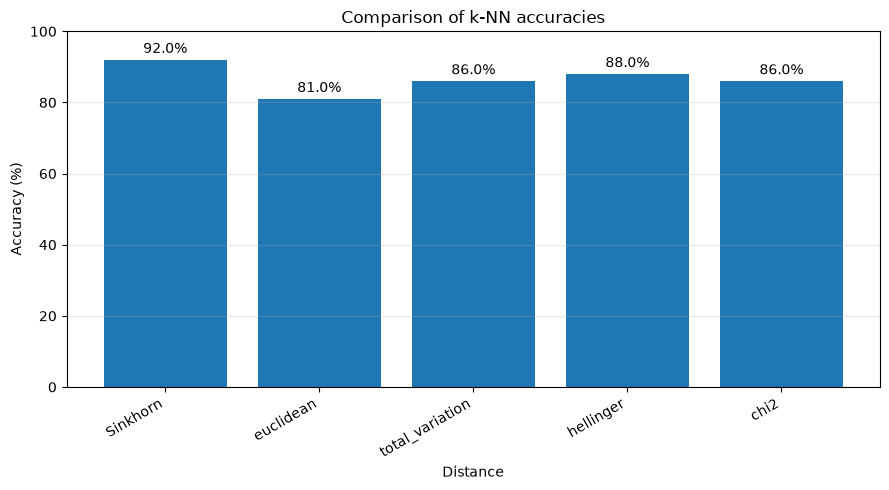

In [28]:
import matplotlib.pyplot as plt


metrics = list(metrics)
scores = np.array(scores, dtype=float)
# Convert to percentage if scores are between 0 and 1
if np.max(scores) <= 1:
    scores = 100 * scores
plt.figure(figsize=(9, 5))
bars = plt.bar(metrics, scores)
plt.title("Comparison of k-NN accuracies")
plt.xlabel("Distance")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
# Add accuracy values above bars
for bar, score in zip(bars, scores):
    plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            f"{score:.1f}%",
            ha="center",
            va="bottom"
        )

plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

We can see that the Sinkhorn distance gives the best overall result among all the distances. The closest one is the Hellinger distance, with an accuracy of 88%.

This suggests that the Sinkhorn distance is a very effective way to compare probability distributions.


## Conclusion

In this notebook, we studied the Sinkhorn distance and applied it to MNIST classification with a k-nearest neighbors classifier.

The main idea comes from optimal transport: comparing two distributions by measuring the minimal effort needed to move the mass of one distribution onto the other. For MNIST, this means seeing pixel intensities as masses on a grid and using the geometry of the image to compare digits.

The Sinkhorn distance adds entropic regularization to make this optimal transport problem easier to compute. In our experiment, even on a reduced subset of MNIST, it gave better results than the other distances we tested.

This suggests that Sinkhorn distance is a powerful way to compare images as probability distributions, although it remains more computationally expensive than classical distances.
